# Learning the player as they play

Everything so far separates measuring a player from advising them: first a fitting session
(notebooks 07 and 09), then a policy solved for the fitted $\sigma$. This notebook closes
the loop. The player names an ability band, which sets a **prior**; every dart of ordinary
match play **updates** it; and each recommendation is made under the current posterior --
so the advice sharpens as the game goes on, with no measurement session at all.

The three pieces, all built on existing machinery (`darts/bayes.py`):

* **Prior.** "I'm a club player" places a lognormal-shaped prior over the shared $\sigma$
  grid, centred at that band with adjacent bands about one standard deviation away.
* **Update.** The likelihood of an observed score value given the aim point,
  $p(s \mid t, \sigma)$, is exact on the pixel grid -- a sum of the Gaussian over the
  pixels of that score. One posterior update costs microseconds. A dart that *finishes* a
  leg is extra information: it is known to have landed in the double bed itself.
* **Action.** The recommendation is not the policy at the posterior mean but the aim point
  maximising the **posterior-weighted Q-value** across MDPs solved on a grid of sigmas,
  $\arg\max_a \sum_\sigma w_\sigma\, Q_\sigma(\text{state}, a)$. A posterior straddling two
  abilities can prefer a hedge that neither ability's own policy would choose.

Assumptions worth stating: isotropic Gaussian throw, no systematic bias, and the score
value of every dart observed (players see where their darts land, busts included). The
zero-bias assumption is the strong one -- it is what lets the posterior live on a 1-D grid
-- and relaxing it is where notebook 09's confounding result would start to bite.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts import players
from darts.bayes import (BayesRecommender, SigmaPosterior, band_prior,
                         flat_prior, play_leg)
from darts.utils import aim_description

SIGMA_GRID = players.SIGMA_GRID                 # 5.0 .. 32.0 in 0.5 mm steps
SOLVE_GRID = np.arange(6.0, 31.0, 2.0)          # the MDPs behind the Q-values

t0 = time.perf_counter()
rec = BayesRecommender(SOLVE_GRID, board_pixels=256, point_stride=2)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s, '
      f'{len(rec.points)} shared aiming points')

13 MDPs solved in 48s, 8109 shared aiming points


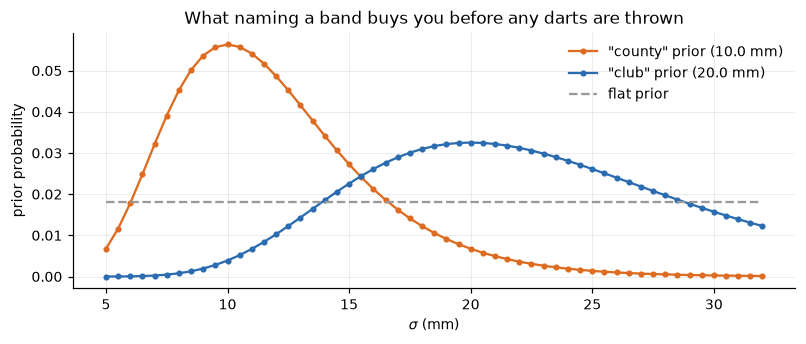

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 3.2))
for band, colour in [('county', '#dd6b20'), ('club', '#2b6cb0')]:
    ax.plot(SIGMA_GRID, band_prior(band, SIGMA_GRID), 'o-', ms=3, color=colour,
            label=f'"{band}" prior ({players.ABILITY_BANDS[band]} mm)')
ax.plot(SIGMA_GRID, flat_prior(SIGMA_GRID), '--', color='#999', label='flat prior')
ax.set_xlabel(r'$\sigma$ (mm)'); ax.set_ylabel('prior probability')
ax.set_title('What naming a band buys you before any darts are thrown')
ax.legend()
fig.tight_layout()

## One leg, dart by dart

A club player ($\sigma = 20$ mm, which the prior happens to get right) plays a leg of 501
under the recommender. Watch the posterior tighten and the advice move.

In [3]:
TRUE_SIGMA = 20.0
rng = np.random.default_rng(7)
post = SigmaPosterior(SIGMA_GRID, band_prior('club', SIGMA_GRID),
                      board=rec.board, checkouts=rec.checkouts)
rec_log = []
darts = play_leg(rec, post, TRUE_SIGMA, rng, record=rec_log)
first = pd.DataFrame(rec_log)
first['aim'] = [aim_description((r.aim_row, r.aim_col), 256)
                for r in first.itertuples()]
print(f'leg finished in {darts} darts '
      f'({(darts + 2) // 3} visits); posterior now '
      f'{post.mean():.1f} +/- {post.std():.1f} mm')
first[['dart', 'state_score', 'state_dart', 'aim', 'scored',
       'post_mean', 'post_std']].head(12).round(2)

leg finished in 28 darts (10 visits); posterior now 17.7 +/- 2.5 mm


,dart,state_score,state_dart,aim,scored,post_mean,post_std
0,1,501,1,T19,57,18.65,5.35
1,2,444,2,T19,19,17.87,5.12
2,3,425,3,T20,20,17.15,4.88
3,4,405,1,T20,20,16.51,4.63
4,5,385,2,T20,20,15.93,4.38
5,6,365,3,T20,20,15.42,4.14
6,7,345,1,T20,20,14.98,3.92
7,8,325,2,T20,20,14.59,3.72
8,9,305,3,T20,15,15.40,3.57
9,10,290,1,T19,7,16.46,3.59


Three things worth noticing in twelve darts.

The recommender opens at **T19, not T20** -- under a club prior the 19 bed's forgiving
neighbours (7 and 3) beat the 20's dangerous ones (1 and 5), the ability-dependent result
the checkout-chart notebook found. Then watch the posterior *breathe*: a run of single
20s while aiming T20 pulls the mean down toward 14.6 -- singles when aiming at the treble
are what a moderately tight player produces -- and then one 15 and a string of 7s (whole
segments missed) push it back up past 18. Every dart moves the estimate, in the direction
a coach's eye would move it.

After one leg the posterior has already tightened from the prior's $20 \pm 5$-ish to
$17.7 \pm 2.5$ mm. No measurement session happened; the player just played.

## How fast does the posterior find the player?

Twenty legs of match play, three different priors: the honest club player, a player who
*flatters themselves* by claiming county (10 mm, two bands better than the truth), and no
prior at all. The question is how many darts of ordinary play it takes each to find
$\sigma = 20$.

        claims club (true): after  705 darts, posterior 19.05 +/- 0.57 mm (truth 20.0)


  claims county (flatters): after  705 darts, posterior 19.06 +/- 0.56 mm (truth 20.0)


                  no prior: after  672 darts, posterior 19.23 +/- 0.58 mm (truth 20.0)


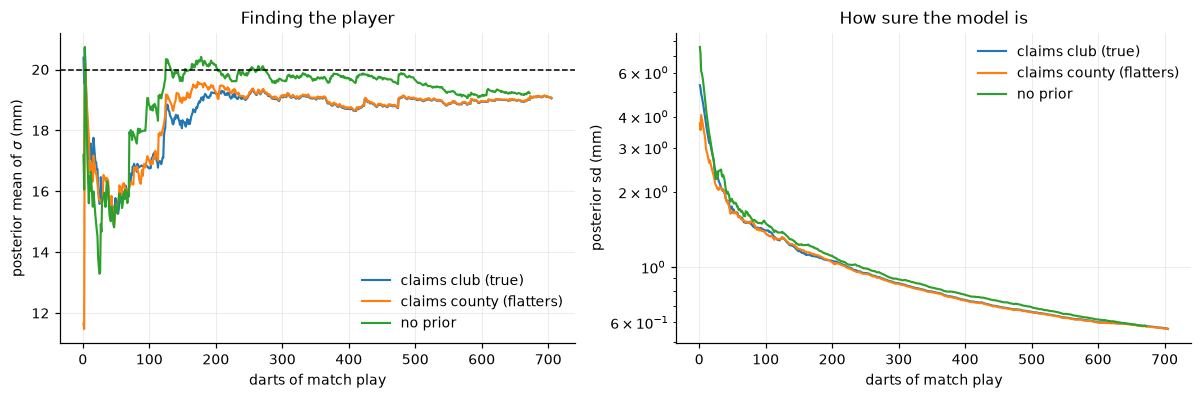

In [4]:
N_LEGS = 20
histories = {}
for name, prior in [('claims club (true)', band_prior('club', SIGMA_GRID)),
                    ('claims county (flatters)', band_prior('county', SIGMA_GRID)),
                    ('no prior', flat_prior(SIGMA_GRID))]:
    rng = np.random.default_rng(42)
    post = SigmaPosterior(SIGMA_GRID, prior, board=rec.board, checkouts=rec.checkouts)
    log = []
    for _ in range(N_LEGS):
        play_leg(rec, post, TRUE_SIGMA, rng, record=log)
    histories[name] = pd.DataFrame(log)
    print(f'{name:>26s}: after {len(log):4d} darts, '
          f'posterior {post.mean():5.2f} +/- {post.std():4.2f} mm '
          f'(truth {TRUE_SIGMA})')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
for name, h in histories.items():
    x = np.arange(1, len(h) + 1)
    axes[0].plot(x, h.post_mean, lw=1.4, label=name)
    axes[1].plot(x, h.post_std, lw=1.4, label=name)
axes[0].axhline(TRUE_SIGMA, color='k', ls='--', lw=1)
axes[0].set_xlabel('darts of match play'); axes[0].set_ylabel(r'posterior mean of $\sigma$ (mm)')
axes[0].set_title('Finding the player'); axes[0].legend()
axes[1].set_xlabel('darts of match play'); axes[1].set_ylabel('posterior sd (mm)')
axes[1].set_yscale('log'); axes[1].set_title('How sure the model is')
axes[1].legend()
fig.tight_layout()

All three priors end in the same place: after twenty legs (about 700 darts) each posterior
sits near $19 \pm 0.6$ mm. The flattering prior -- two full bands wrong -- is
indistinguishable from the honest one within a few legs, and even total ignorance costs
only a slightly wider start. The data simply overwhelm the prior, at the rate of one leg's
worth of evidence per leg.

(This is a single simulated career, so the fact that all three land at 19 rather than
20.0 is one realisation's noise, not a bias -- the mean sits inside its own credible
interval, and the test suite checks the posterior concentrates on the truth over
repeated runs.)

The posterior sd falling as roughly $1/\sqrt{n}$ on the log plot is the Fisher story of
notebook 09 playing out live: ordinary match play is a slowly-run measurement session
that nobody has to schedule.

## Does the learning actually change the darts?

A posterior is only worth carrying if the recommendations differ from what a fixed
assumption would give, by enough to matter. Four ways to play the same player:

* **oracle** -- every dart aimed by the true-$\sigma$ policy. Unattainable; the benchmark.
* **adaptive, honest prior** -- the Bayes loop starting from "club".
* **adaptive, flattering prior** -- the Bayes loop starting from "county".
* **fixed, flattering** -- county's policy used for every dart and *never updated*: what
  actually happens when a club player uses a chart made for a better player.

The score is expected **visits lost per leg**: each dart's value loss against the oracle
action, summed over a leg. This is a low-variance measure -- it charges each decision its
exact expected cost rather than waiting for the noisy realised outcome.

In [5]:
N_LEGS_C = 40
runs = {}
for name, prior, pol in [
        ('oracle', None, 'oracle'),
        ('adaptive, honest prior', band_prior('club', SIGMA_GRID), 'bayes'),
        ('adaptive, flattering prior', band_prior('county', SIGMA_GRID), 'bayes'),
        ('fixed, flattering', None, 10.0)]:
    rng = np.random.default_rng(99)
    post = SigmaPosterior(SIGMA_GRID,
                          prior if prior is not None else flat_prior(SIGMA_GRID),
                          board=rec.board, checkouts=rec.checkouts)
    legs = []
    for _ in range(N_LEGS_C):
        log = []
        play_leg(rec, post, TRUE_SIGMA, rng, policy=pol, record=log)
        legs.append(pd.DataFrame(log))
    runs[name] = legs

rows = []
for name, legs in runs.items():
    per_leg = [l.value_loss.sum() for l in legs]
    rows.append({'strategy': name,
                 'visits lost per leg (first 5 legs)': np.mean(per_leg[:5]),
                 'visits lost per leg (last 20 legs)': np.mean(per_leg[-20:]),
                 'darts per leg': np.mean([len(l) for l in legs])})
pd.DataFrame(rows).set_index('strategy').round(3)

,visits lost per leg (first 5 legs),visits lost per leg (last 20 legs),darts per leg
strategy,,,
oracle,0.000,0.000,34.950
"adaptive, honest prior",0.006,0.000,35.450
"adaptive, flattering prior",0.066,0.000,35.950
"fixed, flattering",0.381,0.333,35.325


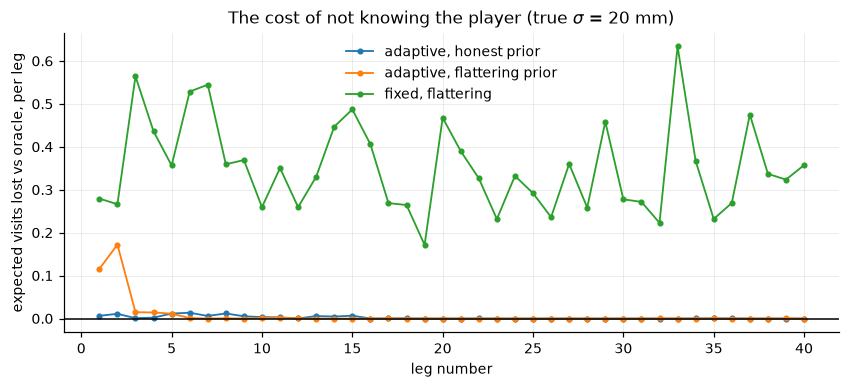

In [6]:
fig, ax = plt.subplots(figsize=(7.8, 3.6))
for name, legs in runs.items():
    if name == 'oracle':
        continue
    per_leg = np.array([l.value_loss.sum() for l in legs])
    ax.plot(np.arange(1, len(per_leg) + 1), per_leg, 'o-', ms=3, lw=1.2, label=name)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('leg number'); ax.set_ylabel('expected visits lost vs oracle, per leg')
ax.set_title(f'The cost of not knowing the player (true $\\sigma$ = {TRUE_SIGMA:.0f} mm)')
ax.legend()
fig.tight_layout()

The ranking is clean, and the units are visits per leg against the unattainable oracle:

* **Adaptive with an honest prior: 0.006 visits per leg in the first five legs, zero
  after.** Starting from the right band, the Bayes recommendations are essentially the
  oracle's from the first dart.
* **Adaptive with a flattering prior: 0.066 for the first five legs, zero after.** The
  self-assessment error is paid for once, cheaply, while the posterior corrects it.
* **Fixed flattering assumption: 0.35 visits per leg, forever.** This is the realistic
  baseline -- a club player using recommendations tuned for a county player and never
  updating. Using notebook 08's exchange rate of about 0.57 visits per millimetre, the
  permanent cost of the un-updated wrong chart is worth roughly **0.6 mm of accuracy** --
  several months of practice, thrown away by not learning from the darts already being
  thrown.

The comparison that matters is the last two rows: the *same wrong belief* costs 0.066
visits once if it is allowed to update, and 0.35 per leg indefinitely if it is not.

## Match play against a measurement session

The posterior narrows during ordinary play -- but is a leg of darts actually a good
measuring instrument, compared with the deliberate sessions of notebook 09? Same budget of
darts, three ways to spend it: match play, a T20 drill, and a drill at the league player's
best measuring target from notebook 09.

(Under this notebook's assumptions the drill is *not* handicapped by the aim-point
confounding -- the bias is assumed known -- so this is a fair fight on information alone.)

posterior sd after 150 darts: match play 1.24, best-target drill 1.06, T20 drill 1.20 mm


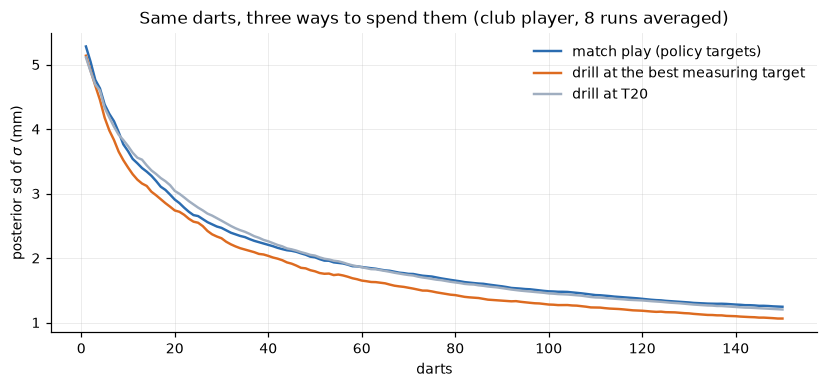

In [7]:
from darts.utils import mm_per_pixel

def drill_posterior(target_mm, n_darts, seed):
    rng = np.random.default_rng(seed)
    post = SigmaPosterior(SIGMA_GRID, band_prior('club', SIGMA_GRID),
                          board=rec.board, checkouts=rec.checkouts)
    px = rec.board.shape[0]
    mmpp = mm_per_pixel(px)
    trace = []
    for _ in range(n_darts):
        land = target_mm + rng.normal(0.0, TRUE_SIGMA, 2)
        col = int(round(land[0] / mmpp)) + px // 2
        row = int(round(land[1] / mmpp)) + px // 2
        v = int(rec.board[row, col]) if 0 <= row < px and 0 <= col < px else 0
        post.update(target_mm, v, pixel=False)
        trace.append(post.std())
    return np.array(trace)

N_BUDGET = 150
t20 = np.mean([drill_posterior(np.array([0.0, 103.0]), N_BUDGET, s) for s in range(8)], axis=0)
best = np.mean([drill_posterior(np.array([0.0, 134.0]), N_BUDGET, s) for s in range(8)], axis=0)

match_traces = []
for s in range(8):
    rng = np.random.default_rng(s)
    post = SigmaPosterior(SIGMA_GRID, band_prior('club', SIGMA_GRID),
                          board=rec.board, checkouts=rec.checkouts)
    log = []
    while len(log) < N_BUDGET:
        play_leg(rec, post, TRUE_SIGMA, rng, record=log)
    match_traces.append(pd.DataFrame(log).post_std.values[:N_BUDGET])
match = np.mean(match_traces, axis=0)

fig, ax = plt.subplots(figsize=(7.6, 3.6))
x = np.arange(1, N_BUDGET + 1)
ax.plot(x, match, lw=1.6, label='match play (policy targets)', color='#2b6cb0')
ax.plot(x, best, lw=1.6, label='drill at the best measuring target', color='#dd6b20')
ax.plot(x, t20, lw=1.6, label='drill at T20', color='#a0aec0')
ax.set_xlabel('darts'); ax.set_ylabel('posterior sd of $\\sigma$ (mm)')
ax.set_title(f'Same darts, three ways to spend them (club player, 8 runs averaged)')
ax.legend()
fig.tight_layout()

print(f'posterior sd after {N_BUDGET} darts: '
      f'match play {match[-1]:.2f}, best-target drill {best[-1]:.2f}, '
      f'T20 drill {t20[-1]:.2f} mm')

The dedicated drill at the best measuring target wins on information per dart, as it
must: after 150 darts its posterior sd is 1.06 mm against match play's 1.24 -- about 37%
more efficient in variance. The T20 drill lands close to match play for this player,
because at $\sigma = 20$ mm T20 is only mildly bad as a target (notebook 09's manifest
puts it at 1.6x the best target's variance for a club player, not the 16-190x it costs
tighter players).

But the units of the comparison are off in match play's favour, twice over. First, the
drill darts are *purchased* -- 150 darts of practice time spent on being measured --
while the match-play darts were being thrown anyway; per unit of *practice time* match
play's information is free. Second, this comparison runs under the zero-bias assumption,
which is precisely the assumption a single-target drill needs and match play does not:
the moment the aim bias is unknown, notebook 09's confounding returns for the drill,
while match play's naturally varied targets are what break it. The honest summary is
that a deliberate session measures fastest, and match play measures *well enough, for
nothing*.

## Does the posterior ever change the *shot*, not just the estimate?

The intro claimed a posterior straddling abilities can prefer an aim point that no single
ability's policy would choose -- a hedge. That is checkable: for every state of the game,
compare the Bayes action under the club prior with the optimal action of *every* sigma on
the solve grid.

In [8]:
post_h = SigmaPosterior(SIGMA_GRID, band_prior('club', SIGMA_GRID),
                        board=rec.board, checkouts=rec.checkouts)
w = rec.weights_from(post_h)
hedges = []
for score in range(2, 171):
    for dart in (1, 2, 3):
        q = rec.qbar(w, score, dart, score)
        a = int(np.argmax(q))
        fixed = {int(np.argmax(m.q_values(score, dart, score))) for m in rec.models}
        if a not in fixed:
            best_fixed = max(q[j] for j in fixed)
            hedges.append({'score': score, 'dart': dart,
                           'hedge aim': aim_description(rec.points[a], 256),
                           'gain over best fixed (visits)': q[a] - best_fixed})
hedges = pd.DataFrame(hedges)
print(f'{len(hedges)} of {169 * 3} states choose an aim no fixed-sigma policy chooses')
hedges.sort_values('gain over best fixed (visits)', ascending=False).head(8).round(4)

83 of 507 states choose an aim no fixed-sigma policy chooses


,score,dart,hedge aim,gain over best fixed (visits)
3,18,3,outside D9,0.0027
23,62,2,T14,0.0021
50,112,1,T19,0.0021
52,112,3,T19,0.0019
62,132,3,T19,0.0018
59,128,3,T19,0.0017
60,132,1,T19,0.0017
58,128,2,T19,0.0016


So hedging is real but cheap: about one state in six picks a genuinely intermediate aim,
and the best of them beats the best fixed-sigma action by only ~0.003 visits. The
posterior's value is overwhelmingly in the *learning* -- getting the right sigma's policy
quickly -- not in the exotic actions taken while uncertain. Which is reassuring for
practice: printing a chart for the posterior mode loses almost nothing over the full
Bayesian action, once the posterior has settled.

## What this adds, and what it leaves out

**Added.** A working closed loop: name a band, play ordinary legs, and the advice
converges to what a solved-for-you policy would say -- within a handful of legs if your
self-assessment was a couple of bands off, immediately if it was right. The alternative
players actually live with, a fixed chart for the wrong standard, measurably costs about
a third of a visit per leg forever. And the loop doubles as the answer to notebook 10's
problem for weaker players: the posterior *is* the running fit across ordinary sessions
that single-session testing cannot replace, accumulating evidence at zero practice-time
cost.

**Left out, in increasing order of how much it would change things.**

* **Anisotropy** -- the posterior grid is 1-D in an isotropic sigma; a real thrower's
  vertical spread exceeds their horizontal. A 2-D or 3-D grid is the same machinery.
* **Bias** -- assumed zero, and it is the strong assumption: with bias unknown the
  single-target confounding of notebook 09 returns, match play's varied targets become
  genuinely necessary rather than merely convenient, and the posterior needs the
  (b, sigma) extension.
* **Drift** -- sigma is assumed constant while the posterior sharpens indefinitely. A
  real player warms up, tires, and improves across weeks. A forgetting factor (tempering
  the log-posterior toward the prior at some rate) turns this into a tracker rather than
  an estimator, and would also make the sd floor honest: after 700 darts the model claims
  +/-0.6 mm, which no human is stable to across a season.
* **The opponent** -- recommendations here optimise the solitaire minimum-visits
  objective, the model the checkout charts argued for. Folding the posterior into the
  two-player leg values is straightforward but changes little (notebook 04 bounded the
  gap at ~1.4 points of win probability).